In [2]:
#First import the various libraries needed
import sys
sys.path.append('/storage/home/hcoda1/9/dmathews33/Spin-tracking/scripts')
import nedmSim
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def E2_shift(gamma, E, B0, V):
    w0 = B0 * gamma
    return gamma**2*E**2*V**2/(3*299792458.0**4*w0)

def analyzeDataset(inpDset, randomSample = False, plot=False):
    errorStates = inpDset[1]['errorState'][-1,:]
    validParticles = np.argwhere(errorStates==0)[:,0]
    times = inpDset[1]['t'][:,0]
    sz = inpDset[1]['s'][:,validParticles,2]
    sy = inpDset[1]['s'][:,validParticles,1]    
    phis = np.arctan2(sz, sy)
    validPhis = np.argwhere(np.logical_not(np.isnan(phis[-1,:])))[:,0]
    phis = phis[:,validPhis]
    for i in range(len(times)):
        if randomSample:
            phis[i,:] = nedmSim.shiftDatapoints(np.random.choice(phis[i,:], size=phis[i,:].shape))
        else:
            phis[i,:] = nedmSim.shiftDatapoints(phis[i,:])
        if plot:
            plt.hist(phis[i,:], bins = 1000)
            plt.title(times[i])
            plt.yscale('log')
            plt.show()
    means = np.nanmean(phis, axis=1)
    means[means > np.pi] -= np.pi*2.0
    means[means < -np.pi] += np.pi*2.0
    stds = np.nanstd(phis, axis=1)
    return times, means, stds, phis.shape[0]

def runTests(parameters, velocities):
    results = []
    for vel in velocities:
        print('\t', vel)
        parameters['V']=str(vel) #set the velocity if using distribution = 'C'
        filename = 'neutronTest.txt'
        nedmSim.writeParameterFile(filename, parameters)
        outputFile = '/storage/home/hcoda1/9/dmathews33/scratch/precisionTest64bit.out'
        !~/Spin-tracking/bit64main {filename} {outputFile}
        results.append(nedmSim.readInOutputFile(outputFile, pad=3))

    finalResults = []
    for res in results:
        finalResults.append(analyzeDataset(res))
    w = results[0][0]['gamma']*np.sqrt(np.sum(np.square(results[0][0]['B0'])))*np.sign(results[0][0]['B0'][0]) #calculate the frequency
    times = results[0][1]['t'][:,0]
    calcZ = np.cos(w*times)
    calcY = np.sin(w*times)
    calcPhase = np.arctan2(calcZ, calcY)
    shifts = []
    for res in finalResults:
        shift = res[1]-calcPhase
        shift[shift > np.pi] -= 2.0*np.pi
        shift[shift < -np.pi] += 2.0*np.pi
        shifts.append(shift)
    shifts = np.array(shifts)
    out = {}
    out['times'] = times
    out['shifts'] = shifts/times/(2.0*np.pi)*1e9
    errs = []
    for res in finalResults:
        errs.append(res[2]/np.sqrt(res[3])/times/(2.0*np.pi)*1e9)
    errs = np.array(errs)
    out['errors'] = errs
    rawVals = []
    for res in finalResults:
        rawVals.append(res[1])
    rawVals = np.array(rawVals)
    out['rawVals'] = rawVals
    out['w'] = w
    out['calcPhase'] = calcPhase
    params = []
    for res in results:
        params.append(res[0])
    out['parameters'] = params
    return out

In [4]:
#Trying to match Matt Morano's testing setup and results

tf = 100.0
tout = 10.0
numParticles = 65536

parameters = {}
parameters['L'] = '1.0, 1.0, 1.0'
parameters['particle'] = 'neutron' #choose particle type
parameters['dist'] = 'C' #velocity distribution method
parameters['T']='0.4' #set the temperature if using the distribution = 'M' option
parameters['gas_coll']='false' #are we doing phonon collisions? yes for helium-3 usually
parameters['diffuse']='0' #diffuse collisions? 0 = specular, 1 = diffuse, 0.5 is 50% diffuse, etc
parameters['gravity']='false' #gravity on or off?
parameters['B0'] = '3.0e-6, 0, 0' #magnetic field
parameters['numParticles'] = str(numParticles) #number of particles
parameters['numPerGPUBlock'] = '256' #number of particles per GPU block, does nothing on CPU
parameters['t0']='0.0' #start time of the simulation
parameters['tf']=str(tf) #stop time of the simulation
parameters['ioutInt']=str(tout) #output interval
parameters['a']= '0' #'19.1024180e-6' #driving field amplitude
parameters['w']='0' #'3000.0' #driving field frequency
parameters['h']='1e-5' #starting step size
parameters['keepStepSize'] = 'false' #do we remember the step size between function calls
parameters['fixedStepSize'] = 'false' #is the step size for spin integration fixed?
parameters['rtol'] = '1.0e-12' #relative precision desired for spin integration
parameters['atol'] = '1.0e-12' #absolute precision desired for spin integration
parameters['hmax'] = '1.0' #largest step size allowed for spin integration
parameters['hmin'] = '1.0e-9' #smallest step size allowed for spin integration
parameters['seed'] = '0' #random number seed for the first particle
parameters['integratorType'] = '2' #the spin integration method

resultsNoGravity = []
resultsGravity = []
velocities = [5]
for e in [0, 50, 75, 100, 125, 150, 175, 200, 225, 250]:
    parameters['gravity'] = 'false'
    parameters['E'] = str(e*1e5)+', 0, 0' #electric field
    print(parameters['E'], parameters['gravity'])
    resultsNoGravity.append(runTests(parameters, velocities))
    parameters['gravity'] = 'true'
    resultsGravity.append(runTests(parameters, velocities))

0.0, 0, 0 false
	 5
648
iter 0, duration 10, 708
iter 1, duration 20, 623
iter 2, duration 30, 622
iter 3, duration 40, 622
iter 4, duration 50, 618
iter 5, duration 60, 619
iter 6, duration 70, 621
iter 7, duration 80, 624
iter 8, duration 90, 619
iter 9, duration 100, 620
6807
	 5
648


/scratch/3680208/ipykernel_18117/1115538569.py:54: RuntimeWarning: divide by zero encountered in true_divide
  out['shifts'] = shifts/times/(2.0*np.pi)*1e9
/scratch/3680208/ipykernel_18117/1115538569.py:57: RuntimeWarning: divide by zero encountered in true_divide
  errs.append(res[2]/np.sqrt(res[3])/times/(2.0*np.pi)*1e9)


iter 0, duration 10, 664
iter 1, duration 20, 653
iter 2, duration 30, 657
iter 3, duration 40, 655
iter 4, duration 50, 652
iter 5, duration 60, 652
iter 6, duration 70, 654
iter 7, duration 80, 653
iter 8, duration 90, 652
iter 9, duration 100, 653
6801
5000000.0, 0, 0 false
	 5
648
iter 0, duration 10, 551
iter 1, duration 20, 542
iter 2, duration 30, 541
iter 3, duration 40, 541
iter 4, duration 50, 542
iter 5, duration 60, 540
iter 6, duration 70, 544
iter 7, duration 80, 541
iter 8, duration 90, 542
iter 9, duration 100, 541
5690
	 5
648
iter 0, duration 10, 10184
iter 1, duration 20, 10140
iter 2, duration 30, 10133
iter 3, duration 40, 10155
iter 4, duration 50, 10152
iter 5, duration 60, 10127
iter 6, duration 70, 10147
iter 7, duration 80, 10156
iter 8, duration 90, 10141
iter 9, duration 100, 10141
101732
7500000.0, 0, 0 false
	 5
648
iter 0, duration 10, 551
iter 1, duration 20, 545
iter 2, duration 30, 543
iter 3, duration 40, 540
iter 4, duration 50, 542
iter 5, duration 

In [16]:
resultsGravity[0]['rawVals']

(1, 11)

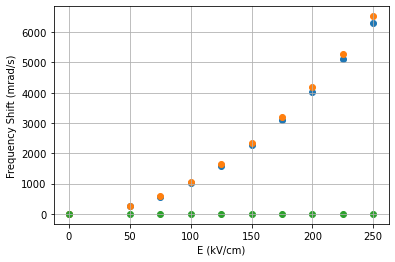

In [12]:
Es = []
shiftsGrav = []
shiftsNoGrav = []
calculatedShifts = []
for resgrav, resnograv in zip(resultsGravity, resultsNoGravity):
    shiftsGrav.append(resgrav['shifts'][0,-1])
    shiftsNoGrav.append(resnograv['shifts'][0,-1])
    Es.append(resgrav['parameters'][0]['E'][0])
    calc = E2_shift(resgrav['parameters'][0]['gamma'], resgrav['parameters'][0]['E'][0], 
                    resgrav['parameters'][0]['B0'][0], resgrav['parameters'][0]['V'])
    calculatedShifts.append(calc)

Es = np.array(Es)
shiftsGrav = np.array(shiftsGrav)
shiftsNoGrav = np.array(shiftsNoGrav)
calculatedShifts = np.array(calculatedShifts)
plt.scatter(Es/1e5, shiftsNoGrav, label='Without Gravity')
plt.scatter(Es/1e5, shiftsGrav, label = 'With Gravity')
plt.scatter(Es/1e5, calculatedShifts*1000, label='Theory')
plt.xlabel('E (kV/cm)')
plt.ylabel('Frequency Shift (mrad/s)')
plt.grid()
plt.show()